Подготовка данных

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import kagglehub
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial.distance import cdist

In [2]:
# Download latest version
path = kagglehub.dataset_download("mathchi/diabetes-data-set")

print("Path to dataset files:", path)

# Показываем список файлов (первые 10)
files = os.listdir(path)
print(files[:10])

# Путь к CSV файлу
csv_path = os.path.join(path, 'diabetes.csv')

# Загрузка в DataFrame
df = pd.read_csv(csv_path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 14.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mathchi/diabetes-data-set/versions/1
['diabetes.csv']


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")

print("Path to dataset files:", path)

# Показываем список файлов (первые 10)
files = os.listdir(path)
print(files[:10])

# Путь к CSV файлу
csv_path = os.path.join(path, 'housing.csv')

# Загрузка в DataFrame
df_1 = pd.read_csv(csv_path)

100%|██████████| 400k/400k [00:00<00:00, 1.06MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1
['housing.csv']


In [ ]:
df_1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [20]:
def generate_data(n_points, noise_level):
    x = np.linspace(-5, 5, n_points)
    y = np.sin(x) + np.random.normal(0, noise_level, n_points)
    return x, y

# Генерация датасета с шумом
n_points = 100
noise_level = 0.2
x_data, y_data = generate_data(n_points, noise_level)

## 1. Ядерная регрессия Надарая-Ватсона

Реализованные функции ядерной регрессии:

In [15]:
# Функция ядра
class Kernels:
    @staticmethod
    def gaussian(u):
        return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

    @staticmethod
    def quadratic (epanechnikov_like):
        mask = np.abs(u) <= 1
        return mask * 0.75 * (1 - u**2)

    @staticmethod
    def triangular(u):
        mask = np.abs(u) <= 1
        return mask * (1 - np.abs(u))

    @staticmethod
    def epanechnikov(u):
        mask = np.abs(u) <= 1
        return mask * 0.75 * (1 - u**2)

# Ядерная регрессия Надарая-Ватсона
class NadarayaWatson:
    def __init__(self, kernel=Kernels.gaussian):
        self.kernel = kernel
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.atleast_2d(X)
        self.y_train = np.array(y)
        return self

    def predict_fixed(self, X_test, h):
        X_test = np.atleast_2d(X_test)
        dists = cdist(X_test, self.X_train)
        weights = self.kernel(dists / h)

        sum_weights = np.sum(weights, axis=1, keepdims=True)
        sum_weights[sum_weights == 0] = 1e-10

        preds = np.sum(weights * self.y_train, axis=1, keepdims=True) / sum_weights
        return preds.flatten()

    def predict_variable(self, X_test, k):
        X_test = np.atleast_2d(X_test)
        dists = cdist(X_test, self.X_train)

        sorted_dists = np.sort(dists, axis=1)
        h_v = sorted_dists[:, [k - 1]]
        h_v[h_v == 0] = 1e-10

        weights = self.kernel(dists / h_v)
        sum_weights = np.sum(weights, axis=1, keepdims=True)
        sum_weights[sum_weights == 0] = 1e-10

        preds = np.sum(weights * self.y_train, axis=1, keepdims=True) / sum_weights
        return preds.flatten()

# Робастная регрессия LOWESS
class LOWESS:
    def __init__(self, kernel=Kernels.epanechnikov, steps=3):
        self.kernel = kernel
        self.steps = steps

    def fit_predict(self, X, y, k):
        X = X.flatten()
        y = y.flatten()
        n = len(X)
        preds = np.zeros(n)
        delta = np.ones(n)

        for step in range(self.steps):
            for i in range(n):
                dists = np.abs(X - X[i])
                h = np.sort(dists)[k - 1]
                if h == 0: h = 1e-10

                w = self.kernel(dists / h)
                total_w = w * delta

                X_mat = np.vstack([np.ones(n), X]).T
                W_mat = np.diag(total_w)

                try:
                    beta = np.linalg.inv(X_mat.T @ W_mat @ X_mat) @ X_mat.T @ W_mat @ y
                    preds[i] = beta[0] + beta[1] * X[i]
                except np.linalg.linalg.LinAlgError:
                    preds[i] = y[i]

            residuals = y - preds
            s = np.median(np.abs(residuals))
            if s == 0: s = 1e-10

            u = np.abs(residuals) / (6 * s)
            delta = np.where(u < 1, (1 - u**2)**2, 0)

        return preds, delta

## 2. Подбор параметров h, k и ядра K по LOO

Параметр h:

In [6]:
def loo_cv_nw_fixed(X, y, h_grid, kernel):
    best_h = None
    best_score = float('inf')
    n = len(X)

    for h in h_grid:
        errors = []
        nw = NadarayaWatson(kernel=kernel)
        for i in range(n):
            X_train = np.delete(X, i, axis=0)
            y_train = np.delete(y, i)
            nw.fit(X_train, y_train)
            pred = nw.predict_fixed(X[i], h)
            errors.append((y[i] - pred[0])**2)
        score = np.mean(errors)
        if score < best_score:
            best_score = score
            best_h = h
    return best_h

Параметр k:

In [33]:
def loo_cv_nw_variable(X, y, k_grid, kernel):
    best_k = None
    best_score = float('inf')
    n = len(X)

    for k in k_grid:
        errors = []
        nw = NadarayaWatson(kernel=kernel)
        for i in range(n):
            X_train = np.delete(X, i, axis=0)
            y_train = np.delete(y, i)
            nw.fit(X_train, y_train)
            pred = nw.predict_variable(X[i], k)
            errors.append((y[i] - pred[0])**2)
        score = np.mean(errors)
        if score < best_score:
            best_score = score
            best_k = k
    return best_k

### 3. Сравнение 3 ядер

Функция (без обучения), которая при вызове будет применять каждое из 3-х ядер, а затем сравнивать

In [37]:
def find_best_kernel_and_params_loo(X, y):
    kernels_pool = {
        "Гауссовское": Kernels.gaussian,
        "Епанечникова": Kernels.epanechnikov,
        "Треугольное": Kernels.triangular
    }

    h_grid = np.linspace(0.2, 2.5, 10)
    k_grid = np.unique(np.linspace(5, 30, 8, dtype=int))

    best_overall_score_h = float('inf')
    best_overall_score_k = float('inf')

    best_kernel_fixed = None
    best_kernel_variable = None

    opt_h = None
    opt_k = None

    for kernel_name, kernel_func in kernels_pool.items():

        h_local_best = None
        h_local_min_score = float('inf')
        n = len(X)

        for h in h_grid:
            errors = []
            nw = NadarayaWatson(kernel=kernel_func)
            for i in range(n):
                X_train = np.delete(X, i, axis=0)
                y_train = np.delete(y, i)
                nw.fit(X_train, y_train)
                pred = nw.predict_fixed(X[i], h)
                errors.append((y[i] - pred[0])**2)
            score = np.mean(errors)
            if score < h_local_min_score:
                h_local_min_score = score
                h_local_best = h

        if h_local_min_score < best_overall_score_h:
            best_overall_score_h = h_local_min_score
            best_kernel_fixed = kernel_func
            opt_h = h_local_best
            name_fixed_print = kernel_name

        k_local_best = None
        k_local_min_score = float('inf')

        for k in k_grid:
            errors = []
            nw = NadarayaWatson(kernel=kernel_func)
            for i in range(n):
                X_train = np.delete(X, i, axis=0)
                y_train = np.delete(y, i)
                nw.fit(X_train, y_train)
                pred = nw.predict_variable(X[i], k)
                errors.append((y[i] - pred[0])**2)
            score = np.mean(errors)
            if score < k_local_min_score:
                k_local_min_score = score
                k_local_best = k

        if k_local_min_score < best_overall_score_k:
            best_overall_score_k = k_local_min_score
            best_kernel_variable = kernel_func
            opt_k = k_local_best
            name_variable_print = kernel_name

    print(f"Лучшее ядро для фикс. окна: {name_fixed_print} (h = {opt_h:.2f})")
    print(f"Лучшее ядро для перем. окна: {name_variable_print} (k = {opt_k})")

    return best_kernel_fixed, opt_h, best_kernel_variable, opt_k

### 4. Графики для одномерной синтетической задачи

Синтетическая одномерная задача выбрана как $y = \sin x + \varepsilon$

In [22]:
x_fine = np.linspace(-5, 5, 500)
y_true = np.sin(x_fine)

nw = NadarayaWatson(kernel=Kernels.gaussian)
nw.fit(x_data[:, None], y_data)

График истинной функции, наблюдения и прогнозы при разных h

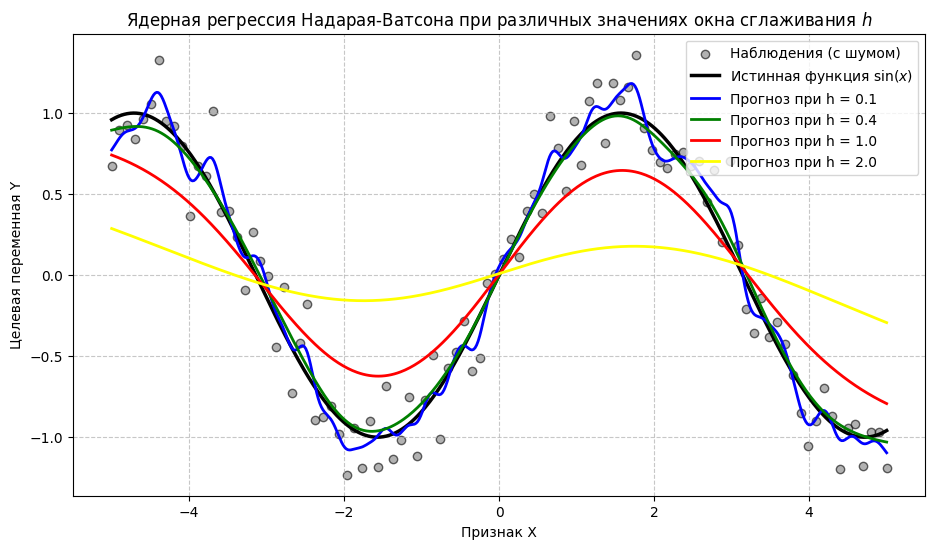

In [28]:
plt.figure(figsize=(11, 6))

plt.scatter(x_data, y_data, color='gray', alpha=0.6, edgecolors='k', label='Наблюдения (с шумом)')
plt.plot(x_fine, y_true, color='black', linewidth=2.5, label=r'Истинная функция $\sin(x)$')
bandwidths = [0.1, 0.4, 1.0, 2.0]
colors = ['blue', 'green', 'red', 'yellow']

for h, col in zip(bandwidths, colors):
    preds = nw.predict_fixed(x_fine[:, None], h)
    plt.plot(x_fine, preds, color=col, linewidth=2, label=f'Прогноз при h = {h}')

plt.title("Ядерная регрессия Надарая-Ватсона при различных значениях окна сглаживания $h$", fontsize=12)
plt.xlabel("Признак X")
plt.ylabel("Целевая переменная Y")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

График: Зависимость ошибки (MSE) от ширины фиксированного окна h

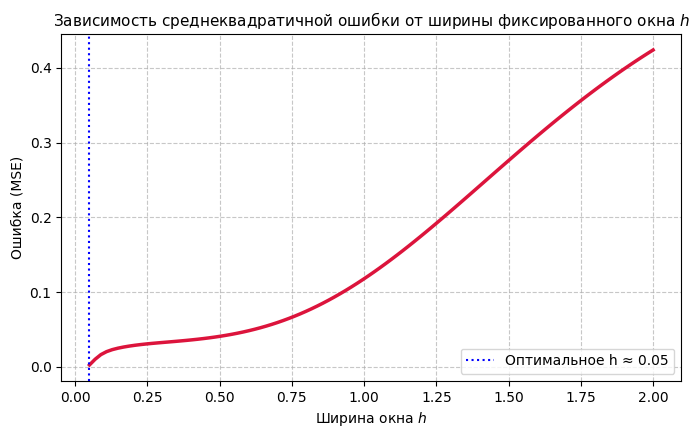

In [29]:
h_grid = np.linspace(0.05, 2.0, 100)
mse_h = []

for h in h_grid:
    preds_h = nw.predict_fixed(x_data[:, None], h)
    mse_h.append(mean_squared_error(y_data, preds_h))

plt.figure(figsize=(8, 4.5))
plt.plot(h_grid, mse_h, color='crimson', linewidth=2.5)
plt.title("Зависимость среднеквадратичной ошибки от ширины фиксированного окна $h$", fontsize=11)
plt.xlabel("Ширина окна $h$")
plt.ylabel("Ошибка (MSE)")
plt.grid(True, linestyle='--', alpha=0.7)

best_h = h_grid[np.argmin(mse_h)]
plt.axvline(best_h, color='blue', linestyle=':', label=f'Оптимальное h ≈ {best_h:.2f}')
plt.legend()
plt.show()

График: Зависимость ошибки (MSE) от числа соседей k для переменного окна

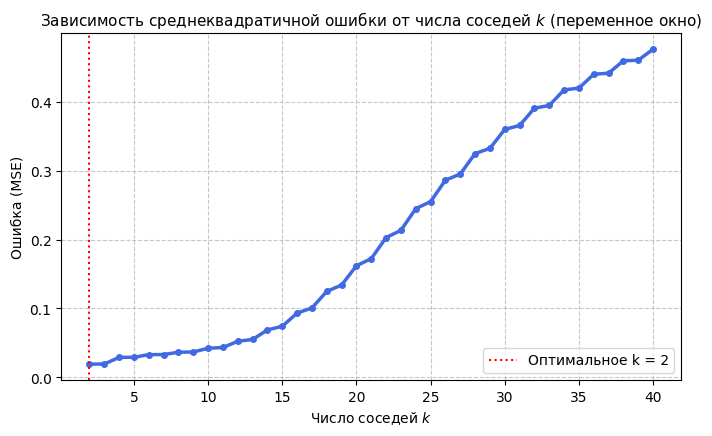

In [30]:
k_grid = np.arange(2, 41)
mse_k = []

for k in k_grid:
    preds_k = nw.predict_variable(x_data[:, None], k)
    mse_k.append(mean_squared_error(y_data, preds_k))

plt.figure(figsize=(8, 4.5))
plt.plot(k_grid, mse_k, color='royalblue', linewidth=2.5, marker='o', markersize=4)
plt.title("Зависимость среднеквадратичной ошибки от числа соседей $k$ (переменное окно)", fontsize=11)
plt.xlabel("Число соседей $k$")
plt.ylabel("Ошибка (MSE)")
plt.grid(True, linestyle='--', alpha=0.7)

best_k = k_grid[np.argmin(mse_k)]
plt.axvline(best_k, color='red', linestyle=':', label=f'Оптимальное k = {best_k}')
plt.legend()
plt.show()

### 5. Оценка качества по метрикам для реальных датасетов

Для реальных датасетов нужно оценить качество по метрикам:

*   MAE
*   RMSE
*   $R^2$

In [39]:
def evaluate_on_real_data_complete(X_raw, y_raw, dataset_name):
    X = StandardScaler().fit_transform(X_raw)
    y = np.array(y_raw)

    if len(X) > 120:
        X, y = X[:120], y[:120]

    print(f"Полученный датасет: {dataset_name}")
    kernel_f, opt_h, kernel_v, opt_k = find_best_kernel_and_params_loo(X, y)

    nw_fixed = NadarayaWatson(kernel=kernel_f)
    nw_fixed.fit(X, y)
    preds_fixed = nw_fixed.predict_fixed(X, h=opt_h)

    nw_variable = NadarayaWatson(kernel=kernel_v)
    nw_variable.fit(X, y)
    preds_variable = nw_variable.predict_variable(X, k=opt_k)

    for method_name, preds in [("Фиксированное окно", preds_fixed),
                               ("Переменное окно", preds_variable)]:
        mae = mean_absolute_error(y, preds)
        rmse = np.sqrt(mean_squared_error(y, preds))
        r2 = r2_score(y, preds)

        print(f"\nРезультаты для [{method_name}]:")
        print(f"- MAE  : {mae:.3f}")
        print(f"- RMSE : {rmse:.3f}")
        print(f"- R^2  : {r2:.3f}")

Датасет Diabets:

In [42]:
X_diabetes = df.drop(columns=['Outcome'])
y_diabetes = df['Outcome']
evaluate_on_real_data_complete(X_diabetes, y_diabetes, "Diabetes Dataset")

Полученный датасет: Diabetes Dataset
Лучшее ядро для фикс. окна: Гауссовское (h = 1.48)
Лучшее ядро для перем. окна: Епанечникова (k = 30)

Результаты для [Фиксированное окно]:
- MAE  : 0.329
- RMSE : 0.382
- R^2  : 0.373

Результаты для [Переменное окно]:
- MAE  : 0.324
- RMSE : 0.390
- R^2  : 0.345


Датасет California

In [43]:
X_housing = df_1.drop(columns=['median_house_value', 'ocean_proximity']).fillna(df_1.median(numeric_only=True))
y_housing = df_1['median_house_value']
evaluate_on_real_data_complete(X_housing, y_housing, "California Housing")

Полученный датасет: California Housing
Лучшее ядро для фикс. окна: Гауссовское (h = 0.46)
Лучшее ядро для перем. окна: Треугольное (k = 22)

Результаты для [Фиксированное окно]:
- MAE  : 30389.898
- RMSE : 49259.695
- R^2  : 0.673

Результаты для [Переменное окно]:
- MAE  : 35790.232
- RMSE : 54834.691
- R^2  : 0.595


### 6. Добавление в данные искусственные выбросы и сравнение обычной ядерной регрессии и LOWESS

Добавление в данные искусственные выбросы:

In [47]:
y_corrupted = y.copy()

y_corrupted[5]  -= 4.2
y_corrupted[15] += 4.5
y_corrupted[50] -= 4.0
y_corrupted[70] += 4.8
y_corrupted[85] += 5.0

Обучение обычной регрессии Надарая-Ватсона и робастного LOWESS

In [48]:
nw_corrupted = NadarayaWatson(kernel=Kernels.epanechnikov)
nw_corrupted.fit(x[:, None], y_corrupted)
preds_nw = nw_corrupted.predict_fixed(x[:, None], h=0.6)

lowess = LOWESS(kernel=Kernels.epanechnikov, steps=3)
preds_lowess, gamma_weights = lowess.fit_predict(x[:, None], y_corrupted, k=25)

Само сравнение:

In [58]:
for name, preds in [("Обычный Надарая-Ватсон", preds_nw), ("Робастный LOWESS", preds_lowess)]:
    mae_c = mean_absolute_error(np.sin(x), preds)
    rmse_c = np.sqrt(mean_squared_error(np.sin(x), preds))
    r2_c = r2_score(np.sin(x), preds)

    print(f"Результаты для [{name}]:")
    print(f"- MAE (отклонение от чистой функции) : {mae_c:.3f}")
    print(f"- RMSE (штраф за крупные промахи)    : {rmse_c:.3f}")
    print(f"- Коэффициент детерминации R^2       : {r2_c:.3f}\n")

Результаты для [Обычный Надарая-Ватсон]:
- MAE (отклонение от чистой функции) : 0.230
- RMSE (штраф за крупные промахи)    : 0.315
- Коэффициент детерминации R^2       : 0.813

Результаты для [Робастный LOWESS]:
- MAE (отклонение от чистой функции) : 0.085
- RMSE (штраф за крупные промахи)    : 0.102
- Коэффициент детерминации R^2       : 0.980



### 7. Графики

График: финальные робастные веса объектов $\gamma_i$ после стабилизации LOWESS

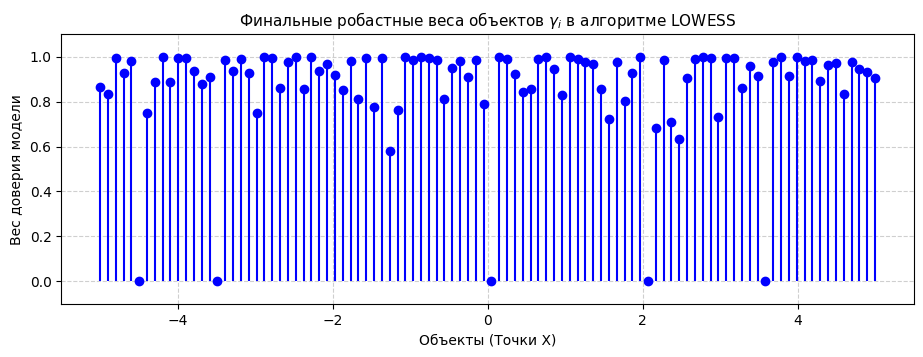

In [56]:
plt.figure(figsize=(11, 3.5))
plt.stem(x_data, gamma_weights, basefmt=" ", linefmt='b-', markerfmt='bo')

plt.title(r"Финальные робастные веса объектов $\gamma_i$ в алгоритме LOWESS", fontsize=11)
plt.xlabel("Объекты (Точки X)")
plt.ylabel("Вес доверия модели")
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

График: сравнение кривых прогноза до и после робастного перевзвешивания

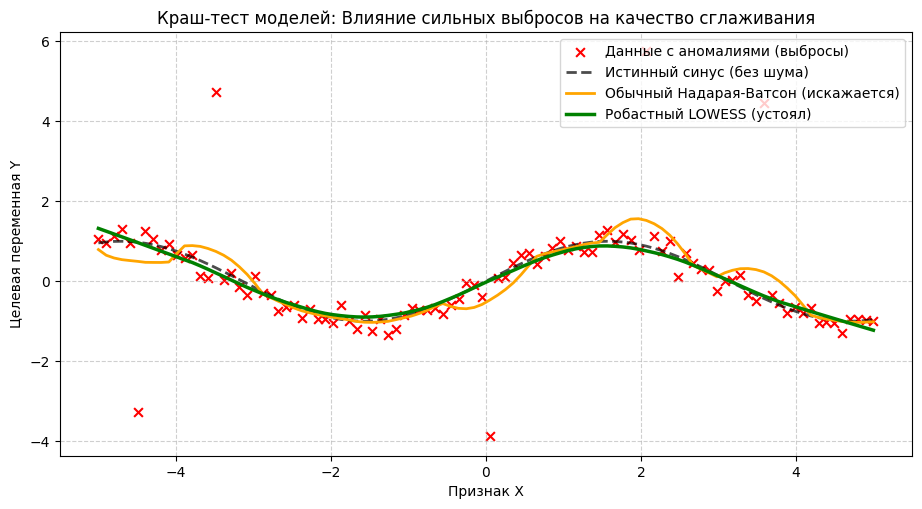

In [57]:
plt.figure(figsize=(11, 5.5))
plt.scatter(x_data, y_corrupted, color='red', marker='x', s=40, label='Данные с аномалиями (выбросы)')
plt.plot(x_data, np.sin(x_data), 'k--', alpha=0.7, linewidth=2, label='Истинный синус (без шума)')
plt.plot(x_data, preds_nw, color='orange', linewidth=2, label='Обычный Надарая-Ватсон (искажается)')
plt.plot(x_data, preds_lowess, color='green', linewidth=2.5, label='Робастный LOWESS (устоял)')

plt.title("Краш-тест моделей: Влияние сильных выбросов на качество сглаживания", fontsize=12)
plt.xlabel("Признак X")
plt.ylabel("Целевая переменная Y")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

График: распределение ошибок на объектах (через гистограмму остатков)

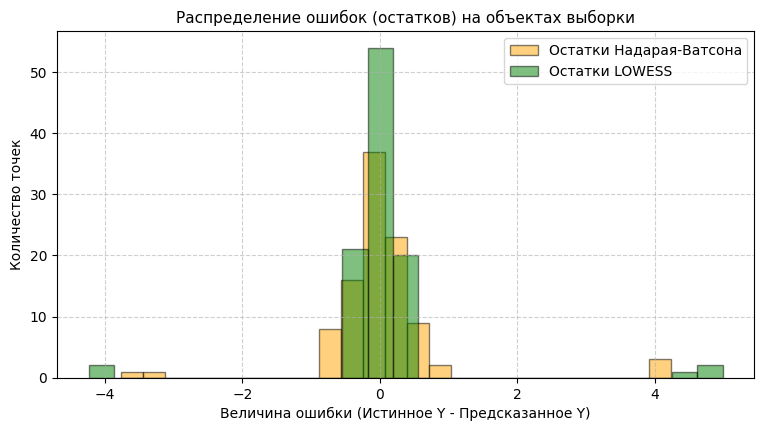

In [55]:
plt.figure(figsize=(9, 4.5))
plt.hist(y_corrupted - preds_nw, bins=25, alpha=0.5, label='Остатки Надарая-Ватсона', color='orange', edgecolor='k')
plt.hist(y_corrupted - preds_lowess, bins=25, alpha=0.5, label='Остатки LOWESS', color='green', edgecolor='k')

plt.title("Распределение ошибок (остатков) на объектах выборки", fontsize=11)
plt.xlabel("Величина ошибки (Истинное Y - Предсказанное Y)")
plt.ylabel("Количество точек")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()